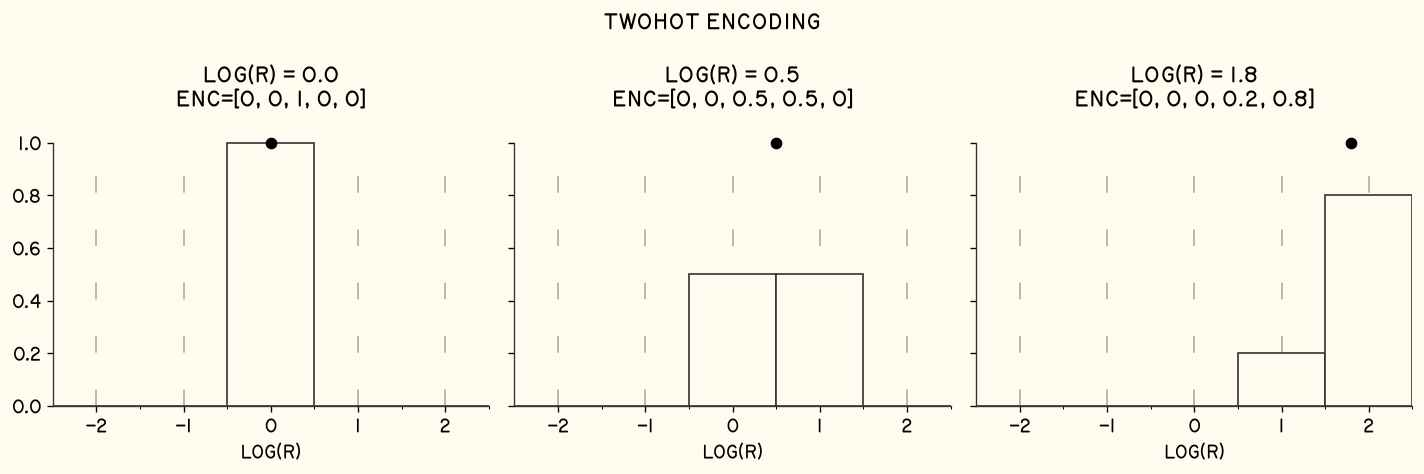

In [11]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

from dreamer.preprocessing import get_bins, symexp, symlog, twohot_decode, twohot_encode

blk = "#333333"
off_white = "#FEFBEF"

plt.rcParams["font.family"] = "Routed Gothic"
plt.rcParams["font.style"] = "normal"
plt.rcParams["font.size"] = 11
plt.rcParams["figure.facecolor"] = off_white
plt.rcParams["axes.facecolor"] = off_white
plt.rcParams["figure.dpi"] = 120


B = get_bins()
x = jax.random.uniform(jax.random.key(4), shape=(4, 5)) * 80

encoded = twohot_encode(symlog(x), B)
decoded = symexp(twohot_decode(encoded, B))
jnp.isclose(decoded, x)


B_logspace = jnp.arange(-4, 5)

fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=True)
r_vals = jnp.array([0.0, 0.5, 1.8])
encs = [
    "[0, 0, 1, 0, 0]",
    "[0, 0, 0.5, 0.5, 0]",
    "[0, 0, 0, 0.2, 0.8]",
]
for ax, r, enc in zip(axes, r_vals, encs):
    encoding = twohot_encode(r, B)

    ax.bar(B, encoding, width=1.0, color=off_white, edgecolor=blk)
    ax.scatter(r, jnp.ones_like(r), c="k", zorder=3)

    ax.set_xlim(-2.5, 2.5)
    ax.set_ylim(0, 1.1)
    ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)
    ax.spines["left"].set_bounds(0, 1)
    ax.spines[["left", "bottom"]].set_color(blk)

    ax.set_xticks(jnp.arange(-2, 3) + 0.5, minor=True)
    ax.set_xticks(jnp.arange(-2, 3))
    ax.vlines(
        ax.get_xticks()[:],
        ymin=0,
        ymax=1,
        color=blk,
        linestyle="--",
        dashes=(0, (10, 22)),
        zorder=0,
        linewidth=1.0,
        alpha=0.4,
    )

    ax.set_xlabel("LOG(R)")
    ax.set_title(f"LOG(R) = {r:.1f}\nENC={enc}")

plt.suptitle("TWOHOT ENCODING")
plt.tight_layout()
plt.savefig("../../assets/twohot.png", dpi=300)
plt.show()

In [6]:
encoding

Array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.20000005, 0.79999995, 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        ], dtype=float32)